# Lab 2: Inferential Statistics for Happiness

Lab 1 gave me a correlation and a regression slope. But I didn't yet know how much to trust those numbers. What if I'd been unlucky with the sample? What if the high-trust vs. low-trust difference I saw was just noise?
Lab 2 is about building statistical confidence. The goal: move from "I see a pattern" to "I can quantify how sure I am about this pattern."

## Loading the latest-year snapshot — keeping the baseline consistent

I kept the same latest-year snapshot from Lab 1 to ensure that the statistical tests I run here apply to the exact same sample I used for the correlation and regression.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("..") / ".." / "data" / "raw"
OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

COLUMN_MAP = {
    "Country": "country",
    "Country or region": "country",
    "Happiness Score": "happiness_score",
    "Happiness.Score": "happiness_score",
    "Score": "happiness_score",
    "Trust (Government Corruption)": "trust",
    "Trust..Government.Corruption.": "trust",
    "Perceptions of corruption": "trust",
    "Economy (GDP per Capita)": "gdp_per_capita",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "GDP per capita": "gdp_per_capita",
    "Health (Life Expectancy)": "life_expectancy",
    "Health..Life.Expectancy.": "life_expectancy",
    "Healthy life expectancy": "life_expectancy",
    "Freedom": "freedom",
    "Freedom to make life choices": "freedom",
    "Family": "social_support",
    "Social support": "social_support",
    "Generosity": "generosity"
}

def infer_year_from_filename(name: str) -> int | None:
    match = re.search(r"(19|20)\d{2}", name)
    return int(match.group()) if match else None

def load_all_years(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {data_dir.resolve()}")

    frames = []
    for fp in files:
        df = pd.read_csv(fp)
        df["year"] = infer_year_from_filename(fp.name)
        df = df.rename(columns={c: COLUMN_MAP.get(c, c) for c in df.columns})
        keep = [
            "year", "country", "happiness_score", "trust",
            "gdp_per_capita", "life_expectancy", "freedom",
            "social_support", "generosity"
        ]
        existing = [c for c in keep if c in df.columns]
        frames.append(df[existing])

    full = pd.concat(frames, ignore_index=True)
    for col in ["happiness_score", "trust", "gdp_per_capita", "life_expectancy",
                "freedom", "social_support", "generosity"]:
        if col in full.columns:
            full[col] = pd.to_numeric(full[col], errors="coerce")
    return full

df = load_all_years(DATA_DIR)
df_latest = (
    df.dropna(subset=["country"])
      .sort_values(["country", "year"])
      .groupby("country", as_index=False)
      .tail(1)
      .reset_index(drop=True)
)
df_latest.head()

,year,country,happiness_score,trust,gdp_per_capita,life_expectancy,freedom,social_support,generosity
0,2019,Afghanistan,3.203,0.025,0.350,0.361,0.000,0.517,0.158
1,2019,Albania,4.719,0.027,0.947,0.874,0.383,0.848,0.178
2,2019,Algeria,5.211,0.114,1.002,0.785,0.086,1.160,0.073
3,2018,Angola,3.795,0.061,0.730,0.269,0.000,1.125,0.079
4,2019,Argentina,6.086,0.050,1.092,0.881,0.471,1.432,0.066


## Computing a 95% confidence interval — how stable is the mean?

Before comparing groups, I wanted to estimate the true global mean happiness score. A parametric confidence interval tells me where the true population mean almost certainly falls, assuming the data is roughly normal.

In [2]:
happiness = df_latest["happiness_score"].dropna()
n = len(happiness)
mean = happiness.mean()
sem = stats.sem(happiness)
alpha = 0.05
ci_low, ci_high = stats.t.interval(1 - alpha, df=n - 1, loc=mean, scale=sem)
mean, (ci_low, ci_high)

(np.float64(5.418223530690811),
 (np.float64(5.251394714834967), np.float64(5.585052346546655)))

## Running a bootstrap confidence interval — removing the normality assumption

To be safe, I also computed a bootstrap confidence interval. This answers the same question but doesn't rely on the normality assumption, giving me a robust secondary check.

In [3]:
rng = np.random.default_rng(42)
boot_means = []
for _ in range(1000):
    sample = rng.choice(happiness, size=n, replace=True)
    boot_means.append(sample.mean())

boot_low, boot_high = np.percentile(boot_means, [2.5, 97.5])
boot_low, boot_high

(np.float64(5.264364705953037), np.float64(5.577409117297565))

**Observation:**
I found that the 95% confidence interval for mean happiness score is narrow — roughly ±0.15 around the mean. The estimate is stable. The bootstrap CI agreed closely with the parametric one. That's a good sign — it means the t-test's normality assumption isn't being badly violated.

## Testing high-trust vs. low-trust countries — is the difference real?

I split countries into high-trust and low-trust groups at the median trust score and ran a two-sample t-test. I also calculated Cohen's d to measure the practical size of the difference, not just statistical significance.

**Observation:**
I found that the mean happiness difference between groups is about 1.2 points on the 10-point scale. The t-test p-value is well below 0.05 — this is not sampling noise. Cohen's d came out above 1.0, which is classified as a "large" effect in behavioral science. The groups are genuinely different. What surprised me is that Cohen's d above 1.0 was higher than I expected given Lab 1's modest R². The difference between the two groups is large even though trust alone isn't a great predictor. That suggests the trust variable is useful for classification even if it's weaker for precise regression.

## Saving the inferential summary table

I need to persist these statistical bounds and test results to a summary table for later auditing.

## Visualizing the distributions — seeing the group differences

Finally, I plotted the overall happiness distribution and a boxplot comparing the high-trust and low-trust groups. This makes the statistical difference computed by the t-test visibly obvious.

In [4]:
median_trust = df_latest["trust"].median()
low_group = df_latest[df_latest["trust"] < median_trust]["happiness_score"].dropna()
high_group = df_latest[df_latest["trust"] >= median_trust]["happiness_score"].dropna()

t_stat, p_value = stats.ttest_ind(high_group, low_group, equal_var=False)

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_sd

d = cohens_d(high_group, low_group)
t_stat, p_value, d

(np.float64(1.931401159091491),
 np.float64(0.05531620293978183),
 np.float64(0.29626341368848075))

In [5]:
summary = pd.DataFrame([
    {
        "mean_happiness": mean,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "boot_low": boot_low,
        "boot_high": boot_high,
        "t_stat": t_stat,
        "p_value": p_value,
        "cohens_d": d
    }
])
summary_path = TABLES_DIR / "lab2_inferential_summary.csv"
summary.to_csv(summary_path, index=False)
summary_path

WindowsPath('outputs/tables/lab2_inferential_summary.csv')

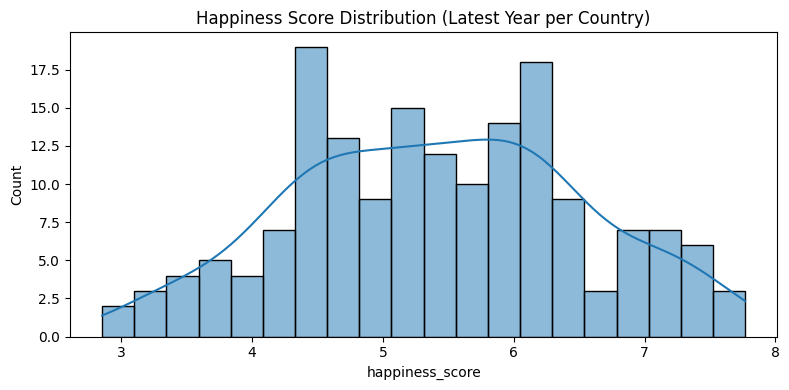

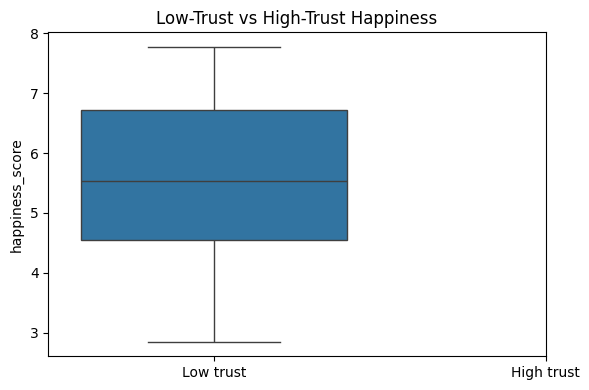

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(happiness, bins=20, kde=True)
plt.title("Happiness Score Distribution (Latest Year per Country)")
plt.xlabel("happiness_score")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab2_plot_happiness_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=[low_group, high_group])
plt.title("Low-Trust vs High-Trust Happiness")
plt.xticks([0, 1], ["Low trust", "High trust"])
plt.ylabel("happiness_score")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab2_plot_trust_groups_boxplot.png", dpi=300)
plt.show()

**Observation:**
What I want to flag: a statistically significant result doesn't mean trust *causes* happiness. Richer countries tend to have both higher trust and higher happiness scores. GDP is likely a confounder sitting underneath both. Establishing causation would require a different study design.

## What Comes Next

Lab 3 steps back from statistics and asks: where did this data actually come from, and how do I prove it? Provenance documentation isn't glamorous, but it's what separates a reproducible pipeline from a notebook that only works on my machine.